# FedProto (Federated Prototype Learning)

### Colab config

In [1]:
# First cell in Colab
from google.colab import drive
drive.mount('/content/drive')

# Check GPU
import torch
print(f"GPU available : {torch.cuda.is_available()}")
print(f"GPU name      : {torch.cuda.get_device_name(0)}")
# Should print: Tesla T4 or similar

# Install dependencies
!pip install torchvision torch -q

Mounted at /content/drive
GPU available : True
GPU name      : Tesla T4


### Setting Working Directory

In [2]:
import os

curr_dir = os.getcwd()
print(f"Current directory: '{curr_dir}'")
os.chdir('/content/drive/MyDrive/BREAST_CANCER_FL/')
print("Changing to root directory...")

print(f"Working in: '{os.getcwd()}'")

Current directory: '/content'
Changing to root directory...
Working in: '/content/drive/MyDrive/BREAST_CANCER_FL'


### Environment Setup & Imports

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
import copy
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from torch.utils.data import DataLoader, Dataset, TensorDataset, WeightedRandomSampler
from torchvision import transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Set Working Directory
BASE_PATH = '/content/drive/MyDrive/BREAST_CANCER_FL/'
os.chdir(BASE_PATH)
import sys
sys.path.append(BASE_PATH)

from model_architectures import (
    EMBEDDING_DIM,
    Hospital1_MLP, Hospital2_MLP, Hospital3_CNN
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

os.makedirs(os.path.join(BASE_PATH, 'models/federated/fedproto'), exist_ok=True)
os.makedirs(os.path.join(BASE_PATH, 'results/federated/fedproto'), exist_ok=True)

print("="*70)
print("  STEP 3 — FedProto (Prototype Representation Sharing)")
print("="*70)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using Device: cuda
  STEP 3 — FedProto (Prototype Representation Sharing)


### Data Loading

In [4]:
print("Loading Datasets...")

# Hospital 1 — WDBC
X_train_h1 = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/wdbc/X_train.csv')).values
y_train_h1 = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/wdbc/y_train.csv')).values.flatten()
X_test_h1  = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/wdbc/X_test.csv')).values
y_test_h1  = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/wdbc/y_test.csv')).values.flatten()

train_dataset_h1 = TensorDataset(torch.FloatTensor(X_train_h1), torch.FloatTensor(y_train_h1))
test_dataset_h1 = TensorDataset(torch.FloatTensor(X_test_h1), torch.FloatTensor(y_test_h1))
train_loader_h1 = DataLoader(train_dataset_h1, batch_size=32, shuffle=True)
test_loader_h1 = DataLoader(test_dataset_h1, batch_size=32, shuffle=False)

# Hospital 2 — Coimbra
X_train_h2 = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/coimbra/X_train.csv')).values
y_train_h2 = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/coimbra/y_train.csv')).values.flatten()
X_test_h2  = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/coimbra/X_test.csv')).values
y_test_h2  = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/coimbra/y_test.csv')).values.flatten()

train_dataset_h2 = TensorDataset(torch.FloatTensor(X_train_h2), torch.FloatTensor(y_train_h2))
test_dataset_h2 = TensorDataset(torch.FloatTensor(X_test_h2), torch.FloatTensor(y_test_h2))
train_loader_h2 = DataLoader(train_dataset_h2, batch_size=16, shuffle=True)
test_loader_h2 = DataLoader(test_dataset_h2, batch_size=16, shuffle=False)

# Hospital 3 — BreakHis
class BreakHisDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform  # <-- This line was missing!
        self.images, self.labels = [], []
        for cls, label in [('benign', 0), ('malignant', 1)]:
            cls_dir = os.path.join(root_dir, cls)
            if os.path.exists(cls_dir):
                for img_name in os.listdir(cls_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.images.append(os.path.join(cls_dir, img_name))
                        self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
train_transform_h3 = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15), transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(), norm
])
test_transform_h3 = transforms.Compose([transforms.ToTensor(), norm])

train_dataset_h3 = BreakHisDataset(os.path.join(BASE_PATH, 'data/processed/breakhis/train'), transform=train_transform_h3)
test_dataset_h3 = BreakHisDataset(os.path.join(BASE_PATH, 'data/processed/breakhis/test'), transform=test_transform_h3)

from sklearn.utils.class_weight import compute_class_weight
class_weights_h3 = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=train_dataset_h3.labels)
sample_weights_h3 = [class_weights_h3[l] for l in train_dataset_h3.labels]
sampler_h3 = WeightedRandomSampler(weights=sample_weights_h3, num_samples=len(sample_weights_h3), replacement=True)

# Optimized DataLoaders for CUDA
train_loader_h3 = DataLoader(train_dataset_h3, batch_size=32, sampler=sampler_h3, num_workers=2, pin_memory=True)
test_loader_h3 = DataLoader(test_dataset_h3, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("Data successfully loaded and pinned to memory.")

Loading Datasets...
Data successfully loaded and pinned to memory.


### FedProto Utility Functions

In [5]:
def aggregate_prototypes(local_protos_list):
    """
    Averages the class prototypes from all hospitals.
    local_protos_list: List of dictionaries [{0: tensor, 1: tensor}, ...]
    """
    global_protos = {}
    for class_id in [0, 1]:
        class_tensors = [p[class_id] for p in local_protos_list if class_id in p]
        if class_tensors:
            global_protos[class_id] = torch.stack(class_tensors).mean(dim=0)
    return global_protos

def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_probs, all_labels = [], [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device).float()
            labels = labels.to(device).float().view(-1, 1)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            all_preds.extend((outputs > 0.0).float().cpu().numpy())
            all_probs.extend(torch.sigmoid(outputs).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_labels = np.array(all_labels).flatten()
    try: auc = roc_auc_score(all_labels, np.array(all_probs).flatten())
    except ValueError: auc = 0.0

    return {
        'loss': running_loss / len(dataloader.dataset),
        'accuracy': accuracy_score(all_labels, all_preds),
        'f1': f1_score(all_labels, all_preds, zero_division=0),
        'auc_roc': auc
    }

### Local Training with MSE Prototype Loss

In [6]:
def fedproto_local_train(model, dataloader, criterion, optimizer, global_protos, lamda, device):
    """
    Trains the model and applies MSE loss to pull embeddings toward global prototypes.
    Returns the average classification loss and the newly calculated local prototypes.
    """
    model.train()
    running_loss = 0.0
    mse_loss_fn = nn.MSELoss()

    # Storage for calculating the NEW local prototypes after training
    class_0_embeds, class_1_embeds = [], []

    for inputs, labels in dataloader:
        inputs = inputs.to(device).float()
        labels = labels.to(device).float().view(-1, 1)

        optimizer.zero_grad(set_to_none=True)

        # 1. Forward Pass (Get embedding AND final logit)
        embeddings = model.get_embedding(inputs)
        outputs = model.shared_head(embeddings)

        # 2. Base Classification Loss
        cls_loss = criterion(outputs, labels)

        # 3. FedProto Regularization Loss (Only applied if global_protos exist i.e. Round > 1)
        proto_loss = 0.0
        if global_protos is not None:
            proto_targets = torch.zeros_like(embeddings)
            mask_0 = (labels == 0.0).squeeze()
            mask_1 = (labels == 1.0).squeeze()

            # Map global prototypes to the corresponding samples in the batch
            if mask_0.any() and 0 in global_protos: proto_targets[mask_0] = global_protos[0].to(device)
            if mask_1.any() and 1 in global_protos: proto_targets[mask_1] = global_protos[1].to(device)

            proto_loss = mse_loss_fn(embeddings, proto_targets)

        # 4. Total Loss & Backprop
        total_loss = cls_loss + (lamda * proto_loss)
        total_loss.backward()
        optimizer.step()

        running_loss += cls_loss.item() * inputs.size(0)

        # 5. Store embeddings to calculate local prototypes for the next round
        with torch.no_grad():
            fresh_embeddings = model.get_embedding(inputs)
            mask_0 = (labels == 0.0).squeeze()
            mask_1 = (labels == 1.0).squeeze()
            if mask_0.any(): class_0_embeds.append(fresh_embeddings[mask_0])
            if mask_1.any(): class_1_embeds.append(fresh_embeddings[mask_1])

    # Compute Local Mean Prototypes
    local_protos = {}
    if class_0_embeds: local_protos[0] = torch.cat(class_0_embeds).mean(dim=0).detach().cpu()
    if class_1_embeds: local_protos[1] = torch.cat(class_1_embeds).mean(dim=0).detach().cpu()

    return running_loss / len(dataloader.dataset), local_protos

### The FedProto Training Loop

In [7]:
# ============================================================
# FedProto TRAINING LOOP
# Key difference from FedAvg/FedProx:
#   NO weights are exchanged or averaged.
#   Only the class prototypes (embeddings) are aggregated.
#   Local models use MSE to pull their embeddings toward
#   the global prototypes during local training.
# ============================================================

# INITIALIZING MODELS FROM PHASE 3 WEIGHTS
print("\n Loading Phase 3 trained weights...")

model_h1_proto = Hospital1_MLP(input_size=23, dropout_rate=0.3).to(device)
model_h1_proto.load_state_dict(torch.load(os.path.join(BASE_PATH, 'models/trained/hospital1_local.pth'), map_location=device))

model_h2_proto = Hospital2_MLP(input_size=9, dropout_rate=0.3).to(device)
model_h2_proto.load_state_dict(torch.load(os.path.join(BASE_PATH, 'models/trained/hospital2_local.pth'), map_location=device))

model_h3_proto = Hospital3_CNN(dropout_rate=0.2).to(device)
model_h3_proto.load_state_dict(torch.load(os.path.join(BASE_PATH, 'models/trained/hospital3_local.pth'), map_location=device))

print("    All models loaded from Phase 3")

# OPTIMIZERS (Training both encoder and head locally)
opt_h1_proto = optim.Adam(model_h1_proto.parameters(), lr=0.001)
opt_h2_proto = optim.Adam(model_h2_proto.parameters(), lr=0.001)
opt_h3_proto = optim.Adam(filter(lambda p: p.requires_grad, model_h3_proto.parameters()), lr=0.0001)

# SCHEDULERS
scheduler_h1_proto = optim.lr_scheduler.ReduceLROnPlateau(opt_h1_proto, mode='min', patience=5, factor=0.5)
scheduler_h2_proto = optim.lr_scheduler.ReduceLROnPlateau(opt_h2_proto, mode='min', patience=3, factor=0.5)
scheduler_h3_proto = optim.lr_scheduler.ReduceLROnPlateau(opt_h3_proto, mode='min', patience=5, factor=0.5)

criterion = nn.BCEWithLogitsLoss()

# HYPERPARAMETERS & TRACKING
num_fl_rounds_proto = 25
local_epochs_proto  = 2
best_fl_loss_proto  = float('inf')
lamda               = 0.1   # Prototype regularization strength
global_protos       = None  # Empty in Round 1

fl_history_proto = {
    'round'        : [],
    'h1_train_loss': [], 'h2_train_loss': [], 'h3_train_loss': [],
    'h1_test_acc'  : [], 'h1_test_f1'  : [], 'h1_test_auc': [],
    'h2_test_acc'  : [], 'h2_test_f1'  : [], 'h2_test_auc': [],
    'h3_test_acc'  : [], 'h3_test_f1'  : [], 'h3_test_auc': [],
    'avg_test_acc' : [], 'avg_test_f1' : [], 'avg_test_auc': []
}

print("\n" + "="*70)
print("  FL TRAINING — FedProto (PROTOTYPE SHARING)")
print("="*70)
print(f"\n  Rounds        : {num_fl_rounds_proto}")
print(f"  Local epochs  : {local_epochs_proto}")
print(f"  Lambda (Reg)  : {lamda}")
print(f"  Weighting     : N/A (Prototypes Aggregated, Not Weights)")
print(f"\n  Starting...\n")

for fl_round in range(num_fl_rounds_proto):

    print(f"\n{'='*55}")
    print(f"  FL ROUND {fl_round+1:02d}/{num_fl_rounds_proto} — FedProto")
    print(f"{'='*55}")

    # STEP 1 — Local Training & Prototype Extraction
    print(f"\n   Local Training ({local_epochs_proto} epochs each)...")

    # Hospital 1
    h1_losses = []
    for epoch in range(local_epochs_proto):
        loss, h1_protos = fedproto_local_train(model_h1_proto, train_loader_h1, criterion, opt_h1_proto, global_protos, lamda, device)
        h1_losses.append(loss)
    avg_h1_loss = np.mean(h1_losses)
    print(f"     H1 (WDBC)    : Loss={avg_h1_loss:.4f}")

    # Hospital 2
    h2_losses = []
    for epoch in range(local_epochs_proto):
        loss, h2_protos = fedproto_local_train(model_h2_proto, train_loader_h2, criterion, opt_h2_proto, global_protos, lamda, device)
        h2_losses.append(loss)
    avg_h2_loss = np.mean(h2_losses)
    print(f"     H2 (Coimbra) : Loss={avg_h2_loss:.4f}")

    # Hospital 3
    h3_losses = []
    for epoch in range(local_epochs_proto):
        loss, h3_protos = fedproto_local_train(model_h3_proto, train_loader_h3, criterion, opt_h3_proto, global_protos, lamda, device)
        h3_losses.append(loss)
    avg_h3_loss = np.mean(h3_losses)
    print(f"     H3 (BreakHis): Loss={avg_h3_loss:.4f}")

    # STEP 2 & 3 — Aggregate Global Prototypes
    global_protos = aggregate_prototypes([h1_protos, h2_protos, h3_protos])
    print(f"\n   Global Prototypes (Class 0 & 1) Aggregated")
    print(f"   (No model weights were exchanged)")

    # STEP 6 — Step Schedulers (Using Phase 3 loss)
    scheduler_h1_proto.step(avg_h1_loss)
    scheduler_h2_proto.step(avg_h2_loss)
    scheduler_h3_proto.step(avg_h3_loss)

    # STEP 7 — Evaluate all hospitals
    metrics_h1_proto = evaluate_model(model_h1_proto, test_loader_h1, criterion, device)
    metrics_h2_proto = evaluate_model(model_h2_proto, test_loader_h2, criterion, device)
    metrics_h3_proto = evaluate_model(model_h3_proto, test_loader_h3, criterion, device)

    avg_acc = np.mean([metrics_h1_proto['accuracy'], metrics_h2_proto['accuracy'], metrics_h3_proto['accuracy']])
    avg_f1  = np.mean([metrics_h1_proto['f1'], metrics_h2_proto['f1'], metrics_h3_proto['f1']])
    avg_auc = np.mean([metrics_h1_proto['auc_roc'], metrics_h2_proto['auc_roc'], metrics_h3_proto['auc_roc']])

    # Print Round Summary Table
    results = {
        'Hospital 1 (WDBC)'    : metrics_h1_proto,
        'Hospital 2 (Coimbra)' : metrics_h2_proto,
        'Hospital 3 (BreakHis)': metrics_h3_proto
    }
    print(f"\n  Round {fl_round+1:02d} [FedProto] Results:")
    print(f"  {'Hospital':<25} {'Acc':>6} {'F1':>6} {'AUC':>6}")
    print(f"  {'─'*50}")
    for name, metrics in results.items():
        print(f"  {name:<25} {metrics['accuracy']:>6.4f} {metrics['f1']:>6.4f} {metrics['auc_roc']:>6.4f}")

    print(f"\n  Simple avg — Acc={avg_acc:.4f} F1={avg_f1:.4f} AUC={avg_auc:.4f}")

    # STEP 8 — Save history
    fl_history_proto['round'].append(fl_round + 1)
    fl_history_proto['h1_train_loss'].append(avg_h1_loss)
    fl_history_proto['h2_train_loss'].append(avg_h2_loss)
    fl_history_proto['h3_train_loss'].append(avg_h3_loss)

    fl_history_proto['h1_test_acc'].append(metrics_h1_proto['accuracy'])
    fl_history_proto['h1_test_f1'].append(metrics_h1_proto['f1'])
    fl_history_proto['h1_test_auc'].append(metrics_h1_proto['auc_roc'])

    fl_history_proto['h2_test_acc'].append(metrics_h2_proto['accuracy'])
    fl_history_proto['h2_test_f1'].append(metrics_h2_proto['f1'])
    fl_history_proto['h2_test_auc'].append(metrics_h2_proto['auc_roc'])

    fl_history_proto['h3_test_acc'].append(metrics_h3_proto['accuracy'])
    fl_history_proto['h3_test_f1'].append(metrics_h3_proto['f1'])
    fl_history_proto['h3_test_auc'].append(metrics_h3_proto['auc_roc'])

    fl_history_proto['avg_test_acc'].append(avg_acc)
    fl_history_proto['avg_test_f1'].append(avg_f1)
    fl_history_proto['avg_test_auc'].append(avg_auc)

    # STEP 9 — Save best model based on validation loss
    current_avg_loss = np.mean([metrics_h1_proto['loss'], metrics_h2_proto['loss'], metrics_h3_proto['loss']])

    if current_avg_loss < best_fl_loss_proto:
        best_fl_loss_proto = current_avg_loss

        torch.save(model_h1_proto.state_dict(), os.path.join(BASE_PATH, 'models/federated/fedproto/best_h1_fedproto.pth'))
        torch.save(model_h2_proto.state_dict(), os.path.join(BASE_PATH, 'models/federated/fedproto/best_h2_fedproto.pth'))
        torch.save(model_h3_proto.state_dict(), os.path.join(BASE_PATH, 'models/federated/fedproto/best_h3_fedproto.pth'))

        # Save Global Prototypes
        torch.save(global_protos, os.path.join(BASE_PATH, 'models/federated/fedproto/best_global_protos.pth'))
        print(f"\n   Best saved (avg loss: {best_fl_loss_proto:.4f})")

print("\n" + "="*70)
print("  FedProto TRAINING COMPLETE!")
print("="*70)
print(f"  Best avg loss : {best_fl_loss_proto:.4f}")

# Serialize and Save JSON History
fl_history_proto_serializable = {
    k: [float(v) for v in vals] if isinstance(vals, list) and len(vals) > 0 and isinstance(vals[0], (float, int, np.floating, np.integer)) else vals
    for k, vals in fl_history_proto.items()
}

with open(os.path.join(BASE_PATH, 'results/federated/fedproto/fl_history_fedproto.json'), 'w', encoding='utf-8') as f:
    json.dump(fl_history_proto_serializable, f, indent=4)

print("  History saved: results/federated/fedproto/fl_history_fedproto.json")


 Loading Phase 3 trained weights...
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 185MB/s]


    All models loaded from Phase 3

  FL TRAINING — FedProto (PROTOTYPE SHARING)

  Rounds        : 25
  Local epochs  : 2
  Lambda (Reg)  : 0.1
  Weighting     : N/A (Prototypes Aggregated, Not Weights)

  Starting...


  FL ROUND 01/25 — FedProto

   Local Training (2 epochs each)...
     H1 (WDBC)    : Loss=0.0694
     H2 (Coimbra) : Loss=0.4905
     H3 (BreakHis): Loss=0.2809

   Global Prototypes (Class 0 & 1) Aggregated
   (No model weights were exchanged)

  Round 01 [FedProto] Results:
  Hospital                     Acc     F1    AUC
  ──────────────────────────────────────────────────
  Hospital 1 (WDBC)         0.9561 0.9367 0.9967
  Hospital 2 (Coimbra)      0.7083 0.7200 0.7343
  Hospital 3 (BreakHis)     0.9852 0.9895 0.9995

  Simple avg — Acc=0.8832 F1=0.8821 AUC=0.9102

   Best saved (avg loss: 0.2814)

  FL ROUND 02/25 — FedProto

   Local Training (2 epochs each)...
     H1 (WDBC)    : Loss=0.0710
     H2 (Coimbra) : Loss=0.4824
     H3 (BreakHis): Loss=0.2658

   Glo

### Compare All Methods (FedAvg vs. FedProx vs. FedProto)


  COMPARE ALL METHODS: FedAvg (W) vs FedAvg (Eq) vs FedProx vs FedProto

  FOUR-WAY COMPARISON — BEST ROUND PER METHOD
  Method          : FedAvg Weighted  FedAvg Equal   FedProx        FedProto
  Best round      : 17               1              1              2
  ───────────────────────────────────────────────────────────────────────────────────
  H1 Accuracy     : 0.9825*          0.9825*        0.9649         0.9649 
  H1 F1-Score     : 0.9762*          0.9756         0.9524         0.9500 
  H1 AUC-ROC      : 0.9947           0.9947         0.9931         0.9970*
  H2 Accuracy     : 0.7083           0.7917*        0.7917*        0.7500 
  H2 F1-Score     : 0.7200           0.8148*        0.8148*        0.7500 
  H2 AUC-ROC      : 0.7413*          0.7273         0.7273         0.7343 
  H3 Accuracy     : 0.9946*          0.9556         0.9690         0.9785 
  H3 F1-Score     : 0.9961*          0.9685         0.9779         0.9848 
  H3 AUC-ROC      : 0.9998*          0.9912      

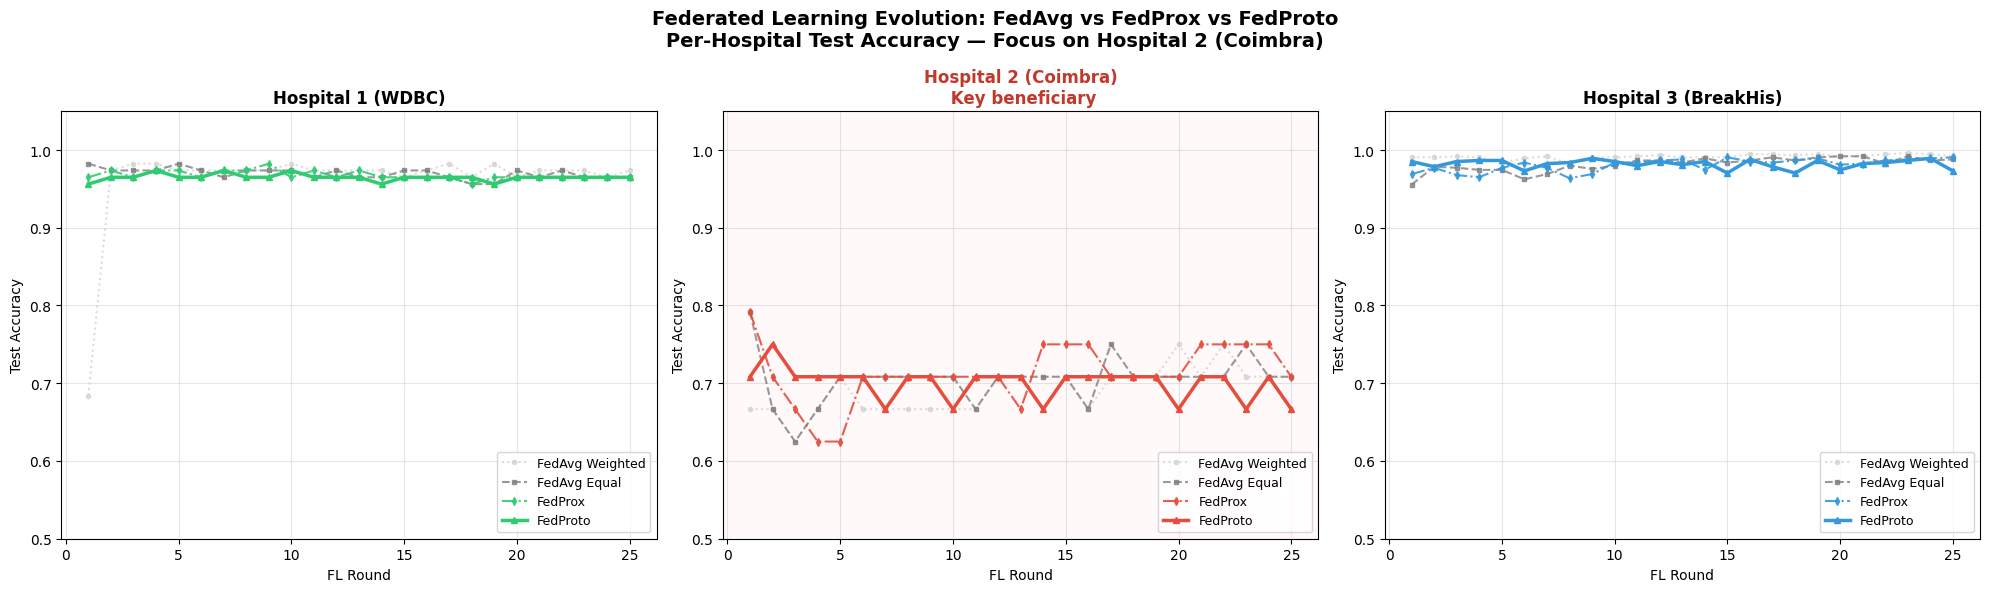


 Comparison plot saved to: /content/drive/MyDrive/BREAST_CANCER_FL/results/federated/fedproto/four_method_comparison.png


In [8]:
# COMPARE: Weighted FedAvg vs Equal FedAvg vs FedProx vs FedProto

print(f"\n{'='*70}")
print("  COMPARE ALL METHODS: FedAvg (W) vs FedAvg (Eq) vs FedProx vs FedProto")
print(f"{'='*70}")

# Loading previous histories
with open(
    os.path.join(BASE_PATH, 'results/federated/fl_history.json'),
    'r', encoding='utf-8'
) as f:
    fl_history_weighted = json.load(f)

with open(
    os.path.join(BASE_PATH, 'results/federated/equal/fl_history_eq.json'),
    'r', encoding='utf-8'
) as f:
    fl_history_equal = json.load(f)

with open(
    os.path.join(BASE_PATH, 'results/federated/fedprox/fl_history_prox.json'),
    'r', encoding='utf-8'
) as f:
    fl_history_prox = json.load(f)

with open(
    os.path.join(BASE_PATH, 'results/federated/fedproto/fl_history_fedproto.json'),
    'r', encoding='utf-8'
) as f:
    fl_history_proto = json.load(f)

# Best round indices (based on average test accuracy to match prior methodology)
best_idx_w     = int(np.argmax(fl_history_weighted['avg_test_acc']))
best_idx_eq    = int(np.argmax(fl_history_equal['avg_test_acc']))
best_idx_prox  = int(np.argmax(fl_history_prox['avg_test_acc']))
best_idx_proto = int(np.argmax(fl_history_proto['avg_test_acc']))

# Numerical comparison table
print(f"\n{'='*85}")
print(f"  FOUR-WAY COMPARISON — BEST ROUND PER METHOD")
print(f"{'='*85}")
print(f"  Method          : FedAvg Weighted  FedAvg Equal   FedProx        FedProto")
print(f"  Best round      : "
      f"{fl_history_weighted['round'][best_idx_w]:<17.0f}"
      f"{fl_history_equal['round'][best_idx_eq]:<15.0f}"
      f"{fl_history_prox['round'][best_idx_prox]:<15.0f}"
      f"{fl_history_proto['round'][best_idx_proto]:.0f}")
print(f"  {'─'*83}")

metrics_to_compare = [
    ('H1 Accuracy', 'h1_test_acc'),
    ('H1 F1-Score', 'h1_test_f1'),
    ('H1 AUC-ROC',  'h1_test_auc'),
    ('H2 Accuracy', 'h2_test_acc'),
    ('H2 F1-Score', 'h2_test_f1'),
    ('H2 AUC-ROC',  'h2_test_auc'),
    ('H3 Accuracy', 'h3_test_acc'),
    ('H3 F1-Score', 'h3_test_f1'),
    ('H3 AUC-ROC',  'h3_test_auc'),
]

for label, key in metrics_to_compare:
    w_val     = fl_history_weighted[key][best_idx_w]
    eq_val    = fl_history_equal[key][best_idx_eq]
    prox_val  = fl_history_prox[key][best_idx_prox]
    proto_val = fl_history_proto[key][best_idx_proto]

    best_val = max(w_val, eq_val, prox_val, proto_val)

    def mark(v):
        return f"{v:.4f}{'*' if v == best_val else ' '}"

    print(f"  {label:<16}: "
          f"{mark(w_val):<17}"
          f"{mark(eq_val):<15}"
          f"{mark(prox_val):<15}"
          f"{mark(proto_val)}")

print(f"  {'─'*83}")
print(f"  * = best for that metric")

# Hospital 2 focus — key finding
print(f"\n  KEY FINDING — Hospital 2 (Coimbra) across methods:")
print(f"  FedAvg Weighted best H2 Acc : {max(fl_history_weighted['h2_test_acc']):.4f}")
print(f"  FedAvg Equal    best H2 Acc : {max(fl_history_equal['h2_test_acc']):.4f}")
print(f"  FedProx         best H2 Acc : {max(fl_history_prox['h2_test_acc']):.4f}")
print(f"  FedProto        best H2 Acc : {max(fl_history_proto['h2_test_acc']):.4f}")

# Plot — Accuracy across all four methods
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    'Federated Learning Evolution: FedAvg vs FedProx vs FedProto\n'
    'Per-Hospital Test Accuracy — Focus on Hospital 2 (Coimbra)',
    fontsize=14, fontweight='bold'
)

hospital_data = [
    ('Hospital 1 (WDBC)',     'h1_test_acc', '#2ECC71'),
    ('Hospital 2 (Coimbra)',  'h2_test_acc', '#E74C3C'),
    ('Hospital 3 (BreakHis)', 'h3_test_acc', '#3498DB'),
]

for i, (name, key, color) in enumerate(hospital_data):
    ax = axes[i]

    # FedAvg Weighted (Light Gray, Dotted)
    ax.plot(
        fl_history_weighted['round'], fl_history_weighted[key],
        color='lightgray', linewidth=1.5, linestyle=':', marker='o', markersize=3,
        label='FedAvg Weighted', alpha=0.8
    )
    # FedAvg Equal (Dark Gray, Dashed)
    ax.plot(
        fl_history_equal['round'], fl_history_equal[key],
        color='gray', linewidth=1.5, linestyle='--', marker='s', markersize=3,
        label='FedAvg Equal', alpha=0.8
    )
    # FedProx (Solid Color, Dash-dot)
    ax.plot(
        fl_history_prox['round'], fl_history_prox[key],
        color=color, linewidth=1.5, linestyle='-.', marker='d', markersize=4,
        label='FedProx', alpha=0.9
    )
    # FedProto (Thick Solid Color, Triangle)
    ax.plot(
        fl_history_proto['round'], fl_history_proto[key],
        color=color, linewidth=2.5, linestyle='-', marker='^', markersize=5,
        label='FedProto', alpha=1.0
    )

    ax.set_title(
        name + ('\n Key beneficiary' if i == 1 else ''),
        fontweight='bold',
        color='#C0392B' if i == 1 else 'black'
    )
    ax.set_xlabel('FL Round')
    ax.set_ylabel('Test Accuracy')
    ax.set_ylim([0.5, 1.05])
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, alpha=0.3)

    if i == 1:
        ax.set_facecolor('#FFF9F9')

plt.tight_layout()
save_path = os.path.join(
    BASE_PATH,
    'results/federated/fedproto/four_method_comparison.png'
)
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"\n Comparison plot saved to: {save_path}")

### Step 3 Summary

In [9]:
# STEP 3 SUMMARY
best_idx_proto = int(np.argmax(fl_history_proto['avg_test_acc']))

summary_proto = f"""
======================================================================
  PHASE 3 SUMMARY: FedProto (Prototype Representation Sharing)
======================================================================
Algorithm     : FedProto
Lambda        : {lamda} (Prototype regularization strength)
FL rounds     : {num_fl_rounds_proto}
Local epochs  : {local_epochs_proto}
Weighting     : N/A (Prototypes Aggregated, Not Weights)
Best round    : {fl_history_proto['round'][best_idx_proto]:.0f}

Results (best round based on Avg Acc):
              FedAvg (W)      FedAvg (Eq)     FedProx         FedProto
H1 Accuracy  {fl_history_weighted['h1_test_acc'][best_idx_w]:.4f}          {fl_history_equal['h1_test_acc'][best_idx_eq]:.4f}          {fl_history_prox['h1_test_acc'][best_idx_prox]:.4f}          {fl_history_proto['h1_test_acc'][best_idx_proto]:.4f}
H2 Accuracy  {fl_history_weighted['h2_test_acc'][best_idx_w]:.4f}          {fl_history_equal['h2_test_acc'][best_idx_eq]:.4f}          {fl_history_prox['h2_test_acc'][best_idx_prox]:.4f}          {fl_history_proto['h2_test_acc'][best_idx_proto]:.4f}
H3 Accuracy  {fl_history_weighted['h3_test_acc'][best_idx_w]:.4f}          {fl_history_equal['h3_test_acc'][best_idx_eq]:.4f}          {fl_history_prox['h3_test_acc'][best_idx_prox]:.4f}          {fl_history_proto['h3_test_acc'][best_idx_proto]:.4f}

H2 best across all methods:
  FedAvg Weighted : {max(fl_history_weighted['h2_test_acc']):.4f}
  FedAvg Equal    : {max(fl_history_equal['h2_test_acc']):.4f}
  FedProx         : {max(fl_history_prox['h2_test_acc']):.4f}
  FedProto        : {max(fl_history_proto['h2_test_acc']):.4f}

Saved files:
  results/federated/fedproto/fl_history_fedproto.json
  results/federated/fedproto/four_method_comparison.png
  results/federated/fedproto/step3_summary.txt
  models/federated/fedproto/best_global_protos.pth
  models/federated/fedproto/best_h1_fedproto.pth
  models/federated/fedproto/best_h2_fedproto.pth
  models/federated/fedproto/best_h3_fedproto.pth

Next: Step 4 — FedProto + FT (Personalization Fine-Tuning)
======================================================================
"""

print(summary_proto)

with open(
    os.path.join(
        BASE_PATH,
        'results/federated/fedproto/step3_summary.txt'
    ),
    'w', encoding='utf-8'
) as f:
    f.write(summary_proto)

print(" Summary saved: results/federated/fedproto/step3_summary.txt")


  PHASE 3 SUMMARY: FedProto (Prototype Representation Sharing)
Algorithm     : FedProto 
Lambda        : 0.1 (Prototype regularization strength)
FL rounds     : 25
Local epochs  : 2
Weighting     : N/A (Prototypes Aggregated, Not Weights)
Best round    : 2

Results (best round based on Avg Acc):
              FedAvg (W)      FedAvg (Eq)     FedProx         FedProto
H1 Accuracy  0.9825          0.9825          0.9649          0.9649
H2 Accuracy  0.7083          0.7917          0.7917          0.7500
H3 Accuracy  0.9946          0.9556          0.9690          0.9785

H2 best across all methods:
  FedAvg Weighted : 0.7500
  FedAvg Equal    : 0.7917
  FedProx         : 0.7917
  FedProto        : 0.7500

Saved files:
  results/federated/fedproto/fl_history_fedproto.json
  results/federated/fedproto/four_method_comparison.png
  results/federated/fedproto/step3_summary.txt
  models/federated/fedproto/best_global_protos.pth
  models/federated/fedproto/best_h1_fedproto.pth
  models/federated/